# Probability Distributions in Real Data

## Purpose and scope

These notes study how a real continuous variable behaves relative to common theoretical probability distributions. The workflow is practical: inspect empirical shape, summarize location and spread, fit candidate distributions, check assumptions visually and statistically, and connect binary variables to Bernoulli/binomial thinking.

Main concepts covered:

- empirical distribution versus theoretical distribution;
- normal, log-normal, and exponential distributions;
- skewness, excess kurtosis, and outliers;
- histogram, KDE, boxplot, and QQ plot;
- Shapiro-Wilk and Kolmogorov-Smirnov tests;
- Bernoulli trials and binomial approximation.

## Prerequisites

Assumed background: basic Python, pandas DataFrames, histograms, and elementary probability. The statistical tests are introduced briefly before use, so the notebook can also work as a compact revision note.

In [ ]:
# Optional installation cell. Uncomment if any package is missing in your environment.
# !pip install numpy pandas matplotlib seaborn scipy statsmodels scikit-learn ucimlrepo openml

## Problem statement

Many machine learning and statistical methods make assumptions about data distributions. For example, linear regression inference often assumes normally distributed residuals, and some anomaly detection methods implicitly depend on distributional assumptions.

In this project, we ask:

> Do real-world continuous variables look normal, log-normal, exponential, or something else?

We will use an insurance charges dataset when it can be loaded from a public URL. If the URL is unavailable, the notebook automatically falls back to the `tips` dataset from seaborn. Both datasets are real tabular datasets and contain positive continuous variables that are useful for studying skewness and probability distributions.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
pd.set_option('display.precision', 4)

from scipy import stats
import statsmodels.api as sm

## Compact concept note

A probability distribution is a model for how values are expected to occur. Real data rarely follows a textbook distribution perfectly because measurements are affected by behavior, policy, natural variability, sampling bias, and data-recording choices. The goal is therefore not to prove that a variable is exactly normal or log-normal, but to decide whether an approximation is reasonable for a particular analysis.

For a continuous variable, the histogram and KDE show the empirical shape. The mean and standard deviation summarize a normal-like variable well, while the median and quantiles are often more stable for skewed data. Skewness measures asymmetry; excess kurtosis measures tail heaviness relative to a normal distribution.

## Dataset description and source

Primary dataset: **Medical insurance charges** loaded directly from a public GitHub raw CSV URL using `pandas.read_csv`.

Fallback dataset: **Seaborn tips dataset**, loaded using `seaborn.load_dataset('tips')`.

The insurance dataset contains variables such as age, BMI, smoking status, region, and medical charges. Medical charges are often strongly right-skewed: most people have moderate expenses, while a smaller number have very high expenses. This makes it a realistic example for distribution analysis.

In [2]:
primary_url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

try:
    df = pd.read_csv(primary_url)
    dataset_name = 'Medical Insurance Charges'
    continuous_candidates = ['charges', 'bmi', 'age']
    binary_candidate = 'smoker'
except Exception as e:
    print('Primary dataset could not be loaded. Falling back to seaborn tips dataset.')
    print('Reason:', e)
    df = sns.load_dataset('tips')
    dataset_name = 'Seaborn Tips'
    continuous_candidates = ['total_bill', 'tip', 'size']
    binary_candidate = 'smoker'

print(dataset_name)
display(df.head())
print('Shape:', df.shape)
print('Columns:', list(df.columns))

Medical Insurance Charges


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.9240
1,18,male,33.770,1,no,southeast,1725.5523
2,28,male,33.000,3,no,southeast,4449.4620
3,33,male,22.705,0,no,northwest,21984.4706
4,32,male,28.880,0,no,northwest,3866.8552


Shape: (1338, 7)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


## Initial data quality check

Before analyzing distributions, always inspect the data structure, missing values, and variable types. Distribution fitting can be misleading if missing values, strings, or coding issues are ignored.

In [3]:
display(df.info())
missing = df.isna().sum().to_frame('missing_count')
missing['missing_percent'] = 100 * missing['missing_count'] / len(df)
display(missing)

display(df.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


None

,missing_count,missing_percent
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207,14.05,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.6634,6.0982,15.96,26.2963,30.4,34.6938,53.13
children,1338.0,NaN,NaN,NaN,1.0949,1.2055,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.4223,12110.0112,1121.8739,4740.2872,9382.033,16639.9125,63770.428


## Choosing variables for distribution analysis

We will focus on one main positive continuous variable. Positive skewed variables are useful because they often violate the normal distribution assumption and may become more symmetric after a log transformation.

In [4]:
available_continuous = [c for c in continuous_candidates if c in df.columns]
main_var = available_continuous[0]
print('Main continuous variable selected:', main_var)

x = pd.to_numeric(df[main_var], errors='coerce').dropna()
print(x.describe())

Main continuous variable selected: charges
count     1338.0000
mean     13270.4223
std      12110.0112
min       1121.8739
25%       4740.2872
50%       9382.0330
75%      16639.9125
max      63770.4280
Name: charges, dtype: float64


## Empirical distribution: histogram and KDE

A histogram shows how observations are distributed across bins. A KDE curve is a smoothed estimate of the distribution shape. Look for symmetry, long tails, multiple peaks, and extreme values.

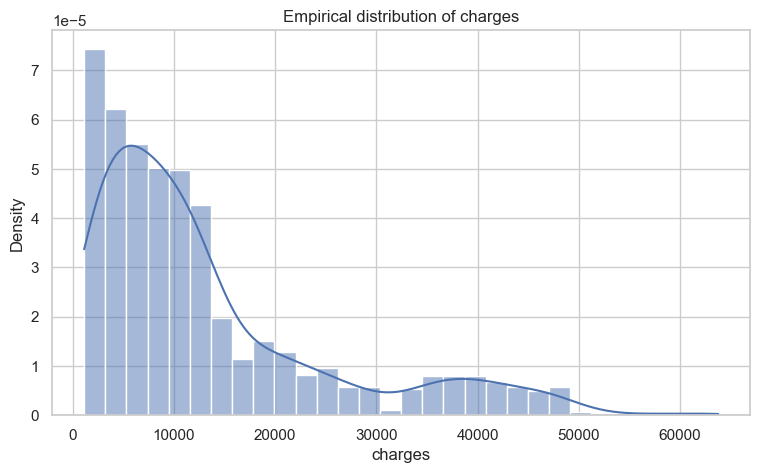

In [5]:
plt.figure(figsize=(9, 5))
sns.histplot(x, kde=True, bins=30, stat='density')
plt.title(f'Empirical distribution of {main_var}')
plt.xlabel(main_var)
plt.ylabel('Density')
plt.show()

### Interpretation guide

After running the cell above, check whether the distribution is symmetric or skewed. If the right tail is much longer than the left tail, the variable is right-skewed. In such cases, the mean is often larger than the median because very large values pull the mean upward.

## Outliers using boxplots

A boxplot summarizes the median, interquartile range, and potential outliers. In real data, outliers are not always errors. For medical expenses, very high charges may represent genuine expensive treatments.

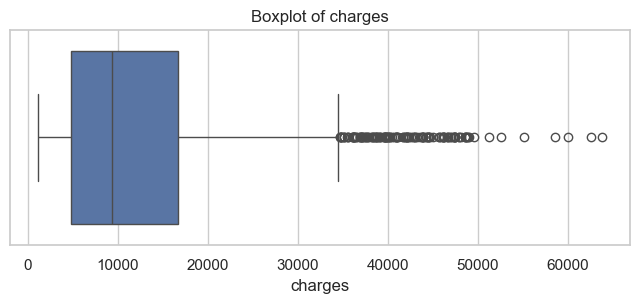

IQR lower fence: -13109.151
IQR upper fence: 34489.351
Potential outliers by 1.5*IQR rule: 139 out of 1338


In [6]:
plt.figure(figsize=(8, 2.8))
sns.boxplot(x=x)
plt.title(f'Boxplot of {main_var}')
plt.xlabel(main_var)
plt.show()

q1, q3 = x.quantile([0.25, 0.75])
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
outlier_count = ((x < lower_fence) | (x > upper_fence)).sum()
print(f'IQR lower fence: {lower_fence:.3f}')
print(f'IQR upper fence: {upper_fence:.3f}')
print(f'Potential outliers by 1.5*IQR rule: {outlier_count} out of {len(x)}')

## Descriptive statistics: location, spread, and shape

The mean and median describe central tendency. Variance and standard deviation describe spread. Skewness describes asymmetry. Kurtosis describes tail heaviness relative to a normal distribution.

In [7]:
stats_summary = pd.Series({
    'count': x.count(),
    'mean': x.mean(),
    'median': x.median(),
    'variance': x.var(ddof=1),
    'std_dev': x.std(ddof=1),
    'skewness': stats.skew(x, bias=False),
    'excess_kurtosis': stats.kurtosis(x, fisher=True, bias=False),
    'min': x.min(),
    'max': x.max()
})
display(stats_summary.to_frame(main_var))

,charges
count,1.3380e+03
mean,1.3270e+04
median,9.3820e+03
variance,1.4665e+08
std_dev,1.2110e+04
skewness,1.5159e+00
excess_kurtosis,1.6063e+00
min,1.1219e+03
max,6.3770e+04


### Interpretation guide

Compare the mean and median. A large gap often indicates skewness. Positive skewness means the right tail is longer. Positive excess kurtosis suggests heavier tails than a normal distribution; negative excess kurtosis suggests lighter tails.

## Fitting theoretical distributions

We will fit three distributions:

1. **Normal distribution**: symmetric bell-shaped distribution.
2. **Log-normal distribution**: useful for positive right-skewed data where the log of the variable is closer to normal.
3. **Exponential distribution**: useful for positive waiting-time-like data with strong right skew.

Fitting does not prove that a distribution is correct. It only gives a candidate mathematical approximation.

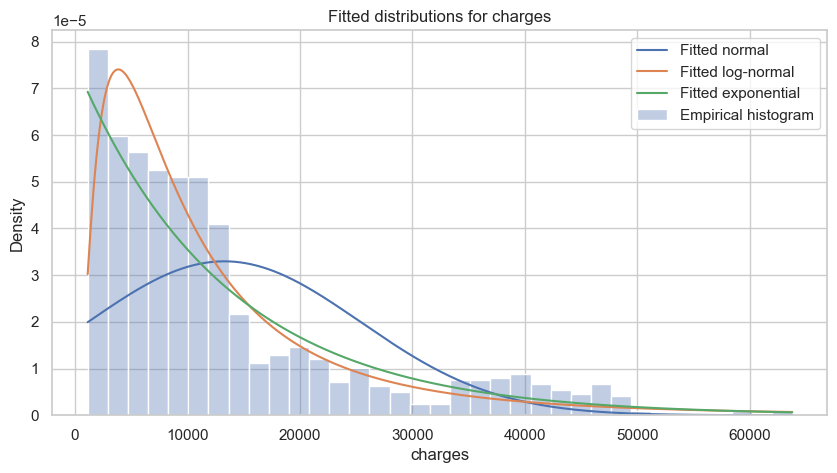

,distribution,parameters
0,normal,"{'mu': 13270.422265141257, 'sigma': 12105.4849..."
1,lognormal,"{'shape': 0.9191834287056958, 'loc': 0.0, 'sca..."
2,exponential,"{'loc': 0.0, 'scale': 13270.422265141257}"


In [8]:
def plot_fitted_distributions(data, variable_name):
    data = pd.Series(data).dropna()
    grid = np.linspace(data.min(), data.max(), 500)

    # Fit parameters
    norm_mu, norm_sigma = stats.norm.fit(data)
    log_shape, log_loc, log_scale = stats.lognorm.fit(data, floc=0) if (data > 0).all() else (np.nan, np.nan, np.nan)
    exp_loc, exp_scale = stats.expon.fit(data, floc=0) if (data >= 0).all() else stats.expon.fit(data)

    plt.figure(figsize=(10, 5))
    sns.histplot(data, bins=35, stat='density', alpha=0.35, label='Empirical histogram')
    plt.plot(grid, stats.norm.pdf(grid, norm_mu, norm_sigma), label='Fitted normal')
    if (data > 0).all():
        plt.plot(grid, stats.lognorm.pdf(grid, log_shape, log_loc, log_scale), label='Fitted log-normal')
    plt.plot(grid, stats.expon.pdf(grid, exp_loc, exp_scale), label='Fitted exponential')
    plt.title(f'Fitted distributions for {variable_name}')
    plt.xlabel(variable_name)
    plt.ylabel('Density')
    plt.legend()
    plt.show()

    params = pd.DataFrame({
        'distribution': ['normal', 'lognormal', 'exponential'],
        'parameters': [
            {'mu': norm_mu, 'sigma': norm_sigma},
            {'shape': log_shape, 'loc': log_loc, 'scale': log_scale},
            {'loc': exp_loc, 'scale': exp_scale}
        ]
    })
    return params

params = plot_fitted_distributions(x, main_var)
display(params)

### Quantitative comparison of fitted distributions

Visual overlays are useful but subjective. The next cell compares candidate distributions using log-likelihood, AIC, and a KS statistic. A lower AIC is better among the fitted candidates. The KS p-value is a strict test of distributional agreement, so it should be interpreted together with the plots rather than used as the only decision rule.

In [9]:
def distribution_fit_summary(data):
    data = pd.Series(data).dropna().astype(float)
    rows = []

    mu, sigma = stats.norm.fit(data)
    ll = np.sum(stats.norm.logpdf(data, mu, sigma))
    ks = stats.kstest((data - mu) / sigma, 'norm')
    rows.append({
        'distribution': 'normal',
        'log_likelihood': ll,
        'num_parameters': 2,
        'AIC': 2 * 2 - 2 * ll,
        'KS_statistic': ks.statistic,
        'KS_p_value': ks.pvalue
    })

    if (data > 0).all():
        shape, loc, scale = stats.lognorm.fit(data, floc=0)
        ll = np.sum(stats.lognorm.logpdf(data, shape, loc, scale))
        ks = stats.kstest(data, 'lognorm', args=(shape, loc, scale))
        rows.append({
            'distribution': 'lognormal',
            'log_likelihood': ll,
            'num_parameters': 2,
            'AIC': 2 * 2 - 2 * ll,
            'KS_statistic': ks.statistic,
            'KS_p_value': ks.pvalue
        })

    if (data >= 0).all():
        loc, scale = stats.expon.fit(data, floc=0)
    else:
        loc, scale = stats.expon.fit(data)
    ll = np.sum(stats.expon.logpdf(data, loc, scale))
    ks = stats.kstest(data, 'expon', args=(loc, scale))
    rows.append({
        'distribution': 'exponential',
        'log_likelihood': ll,
        'num_parameters': 1,
        'AIC': 2 * 1 - 2 * ll,
        'KS_statistic': ks.statistic,
        'KS_p_value': ks.pvalue
    })

    return pd.DataFrame(rows).sort_values('AIC').reset_index(drop=True)

fit_summary = distribution_fit_summary(x)
display(fit_summary)
print('Best AIC candidate:', fit_summary.loc[0, 'distribution'])

,distribution,log_likelihood,num_parameters,AIC,KS_statistic,KS_p_value
0,lognormal,-13959.7924,2,27923.5849,0.0366,5.4294e-02
1,exponential,-14040.0260,1,28082.0519,0.0961,3.2288e-11
2,normal,-14477.6316,2,28959.2632,0.1885,4.3931e-42


Best AIC candidate: lognormal


### Interpretation guide

Compare where the fitted curves match or fail. A normal curve may miss the long right tail. A log-normal curve may represent positive skew better. An exponential curve may be too restrictive if the data has a clear peak away from zero.

## QQ plots: normality before and after log transformation

A QQ plot compares the quantiles of the data with the quantiles expected under a theoretical normal distribution. If points follow a straight line, the normality approximation is more reasonable.

For positive skewed variables, log transformation often reduces skewness.

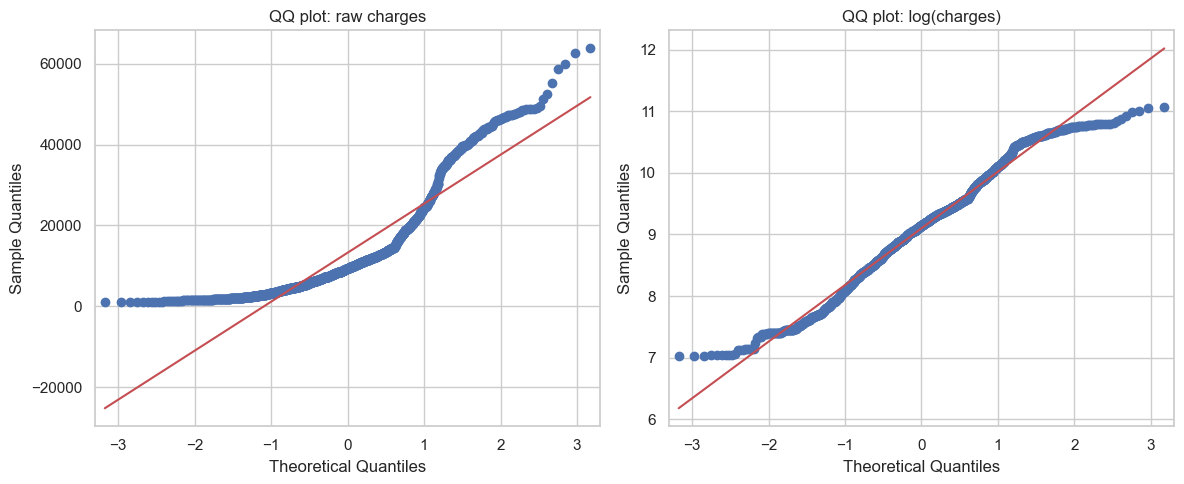

In [10]:
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1)
sm.qqplot(x, line='s', ax=ax1)
ax1.set_title(f'QQ plot: raw {main_var}')

if (x > 0).all():
    log_x = np.log(x)
    ax2 = fig.add_subplot(1, 2, 2)
    sm.qqplot(log_x, line='s', ax=ax2)
    ax2.set_title(f'QQ plot: log({main_var})')
else:
    print('Log transformation skipped because the variable contains non-positive values.')

plt.tight_layout()
plt.show()

### Interpretation guide

Look at the tails of the QQ plot. Curvature in the raw QQ plot indicates deviation from normality. If the log-transformed QQ plot is straighter, the transformation helped. However, the transformed variable still may not be perfectly normal.

## Formal normality tests

We will use:

- **Shapiro-Wilk test**: tests whether data is consistent with normality. It is powerful but can reject normality for small deviations, especially in larger datasets.
- **Kolmogorov-Smirnov test**: compares the sample distribution with a specified theoretical distribution. When parameters are estimated from the same data, treat the p-value as an approximation.

Important: statistical tests answer a strict question. In practical modeling, an approximate distribution may still be useful.

In [11]:
def normality_tests(data, label):
    data = pd.Series(data).dropna()
    # Shapiro-Wilk can be sensitive for large n. We sample at most 5000 as recommended in many practical workflows.
    shapiro_data = data.sample(min(len(data), 5000), random_state=RANDOM_STATE) if len(data) > 5000 else data
    shapiro_stat, shapiro_p = stats.shapiro(shapiro_data)

    mu, sigma = stats.norm.fit(data)
    z = (data - mu) / sigma
    ks_stat, ks_p = stats.kstest(z, 'norm')

    return pd.Series({
        'variable': label,
        'n': len(data),
        'shapiro_statistic': shapiro_stat,
        'shapiro_p_value': shapiro_p,
        'ks_statistic_vs_normal': ks_stat,
        'ks_p_value_vs_normal': ks_p
    })

rows = [normality_tests(x, main_var)]
if (x > 0).all():
    rows.append(normality_tests(np.log(x), f'log({main_var})'))

test_results = pd.DataFrame(rows)
display(test_results)

,variable,n,shapiro_statistic,shapiro_p_value,ks_statistic_vs_normal,ks_p_value_vs_normal
0,charges,1338,0.8147,1.1505e-36,0.1885,4.3931e-42
1,log(charges),1338,0.9832,2.2858e-11,0.0366,5.4294e-02


### Interpretation guide

If p-value < 0.05, the test rejects exact normality at the 5% significance level. This does not automatically mean the variable is unusable. Always combine tests with plots and with the actual purpose of the analysis.

## Bernoulli and binomial variables from real data

A binary variable can be modeled as a Bernoulli random variable: success/failure, yes/no, smoker/non-smoker, etc. The binomial distribution models the number of successes in a fixed number of independent Bernoulli trials with constant probability.

In real data, independence and constant probability may be imperfect. Still, Bernoulli/binomial thinking gives a useful baseline.

Binary variable: smoker
no     1064
yes     274
Name: smoker, dtype: int64
Categories: ['yes' 'no']
Empirical probability of success (yes): 0.2048


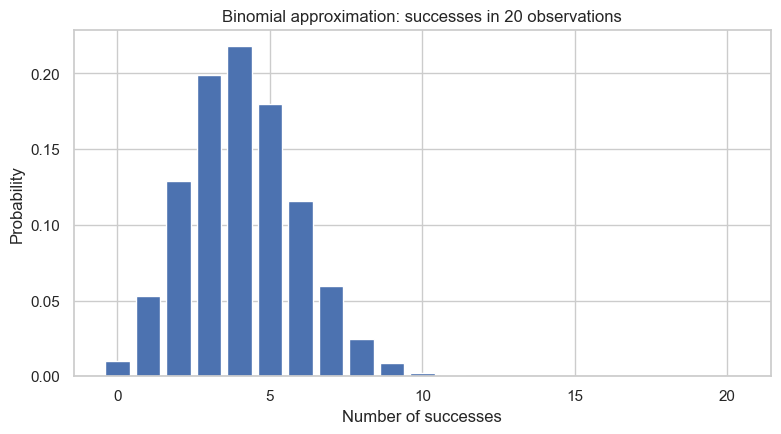

In [12]:
if binary_candidate in df.columns:
    binary_col = binary_candidate
else:
    # fallback: create a binary variable from the main continuous variable
    binary_col = f'{main_var}_above_median'
    df[binary_col] = df[main_var] > df[main_var].median()

print('Binary variable:', binary_col)
print(df[binary_col].value_counts(dropna=False))

# Convert a yes/no-like column to indicator using the most frequent positive-like value when possible.
binary_series = df[binary_col].dropna()
if binary_series.dtype == 'O' or str(binary_series.dtype).startswith('category'):
    print('Categories:', binary_series.unique())
    success_label = binary_series.unique()[0]
    indicator = (binary_series == success_label).astype(int)
else:
    indicator = binary_series.astype(int)
    success_label = 1

p_hat = indicator.mean()
print(f'Empirical probability of success ({success_label}): {p_hat:.4f}')

n_trials = 20
k_values = np.arange(0, n_trials + 1)
binom_probs = stats.binom.pmf(k_values, n_trials, p_hat)

plt.figure(figsize=(9, 4.5))
plt.bar(k_values, binom_probs)
plt.title(f'Binomial approximation: successes in {n_trials} observations')
plt.xlabel('Number of successes')
plt.ylabel('Probability')
plt.show()

### Interpretation guide

The empirical probability is estimated from the dataset. The binomial plot answers: if we randomly sampled 20 comparable observations, how many successes would we expect? This assumes independent observations and a stable probability, which may not strictly hold in observational data.

## What variables looked approximately normal?

Run the following cell to compare several continuous variables. This is a compact summary, not a replacement for plots.

In [13]:
summary_rows = []
for col in available_continuous:
    s = pd.to_numeric(df[col], errors='coerce').dropna()
    if len(s) < 5:
        continue
    row = {
        'variable': col,
        'mean': s.mean(),
        'median': s.median(),
        'std': s.std(ddof=1),
        'skewness': stats.skew(s, bias=False),
        'excess_kurtosis': stats.kurtosis(s, fisher=True, bias=False)
    }
    if (s > 0).all():
        row['log_skewness'] = stats.skew(np.log(s), bias=False)
    summary_rows.append(row)

display(pd.DataFrame(summary_rows))

,variable,mean,median,std,skewness,excess_kurtosis,log_skewness
0,charges,13270.4223,9382.033,12110.0112,1.5159,1.6063,-0.0901
1,bmi,30.6634,30.400,6.0982,0.2840,-0.0507,-0.2567
2,age,39.2070,39.000,14.0500,0.0557,-1.2451,-0.3739


## Output-grounded analytical summary

The next cell converts the computed statistics into a short diagnostic summary. It avoids fixed conclusions before execution and updates automatically if a different dataset or variable is selected.

In [14]:
def shape_label(skew_value):
    if abs(skew_value) < 0.5:
        return 'approximately symmetric'
    if skew_value >= 1:
        return 'strongly right-skewed'
    if skew_value > 0.5:
        return 'moderately right-skewed'
    if skew_value <= -1:
        return 'strongly left-skewed'
    return 'moderately left-skewed'

main_skew = stats.skew(x, bias=False)
mean_median_gap = x.mean() - x.median()
best_fit = fit_summary.loc[0, 'distribution'] if 'fit_summary' in globals() else 'not computed'

analysis_summary = pd.Series({
    'selected_variable': main_var,
    'distribution_shape': shape_label(main_skew),
    'mean_minus_median': mean_median_gap,
    'outlier_count_IQR_rule': outlier_count,
    'best_AIC_candidate_among_tested': best_fit,
    'practical_note': (
        'Use mean/std cautiously when skewness and outliers are large; '
        'median, quantiles, or transformed-scale modeling may be more stable.'
    )
})
display(analysis_summary.to_frame('diagnostic_summary'))

,diagnostic_summary
selected_variable,charges
distribution_shape,strongly right-skewed
mean_minus_median,3888.3893
outlier_count_IQR_rule,139
best_AIC_candidate_among_tested,lognormal
practical_note,Use mean/std cautiously when skewness and outl...


## Limitations

- The fitted distributions are approximations; they do not identify the true data-generating mechanism.
- The IQR outlier rule marks unusual values but cannot decide whether they are errors or meaningful observations.
- Formal normality tests can reject tiny deviations when the sample is large; plots and practical modeling goals must also be considered.
- The binomial approximation assumes independent trials and a stable success probability, which may not strictly hold in observational data.

## What we learned

- Distributional analysis begins with empirical plots, not with a theoretical assumption.
- Skewness explains why the mean and median can differ substantially.
- Log transformation can make a positive right-skewed variable more regular, but not necessarily perfectly normal.
- Goodness-of-fit statistics, QQ plots, and formal tests answer related but different questions.
- Binary columns can be connected to Bernoulli and binomial models, provided the assumptions are stated clearly.

## Possible extensions

- Compare distribution fitting across subgroups, such as smoker versus non-smoker.
- Add robust summaries such as median absolute deviation and trimmed mean.
- Use bootstrap confidence intervals for skewness or the median.
- Fit mixture models when one simple distribution is inadequate.